In [1]:
from nrem_analysis.constant import PROCESSED_DIR, INTERIM_DIR, MOUSE_IDS_DUAL, FIGURES_DIR

import pynapple as nap
import numpy as np
import matplotlib.pyplot as plt
from cmap import Colormap

cm = Colormap("colorbrewer:Set2")

STATE_NAMES = ["continuous", "fragmented", "stationary"]
MOUSE_IDS_DUAL = ["99b", "103c", "106b", "107b", "110b"]
MOVEMENT_VARS = ["movement_var2", "movement_var20"]

### Compute STA

In [2]:
subject_ids = ["99b", "103c", "106b", "107b", "110b"]
mv = 'movement_var20'
for mouse_id in subject_ids:
    data_dir = INTERIM_DIR / mv / mouse_id
    print(f"Processing {mv} / {mouse_id}")
    print(f"--" * 50)

    sleep           = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "sleep.npz")
    turn_units      = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "turn_units.npz")
    session         = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "session.npz")
    nrem            = sleep[sleep['state'] == 'nrem']

    virtual_hds = []
    states      = []
    for i, ep in enumerate(nrem.intersect(session[session['state'] == 'homecage'])):
        decoded = nap.load_file(data_dir / f"{mouse_id}_{i}.npz")
        vh = nap.Tsd(t=decoded.t, d=decoded.values[:, 3])
        virtual_hds.append(vh)
        states_i = nap.TsdFrame(t=decoded.t, d=decoded.values[:, :3], columns=STATE_NAMES)
        states.append(states_i)

    virtual_hds = np.concatenate(virtual_hds)
    states = np.concatenate(states)
    continuous_eps = states['continuous'].threshold(0.5).time_support
    
    # Compute STA on only continuous epochs
    angles = np.deg2rad(virtual_hds)
    angles_cart = np.column_stack([np.sin(angles), np.cos(angles)])
    sta = nap.compute_event_triggered_average(angles_cart, turn_units, binsize=1, window=(-200, 200), time_unit='ms', epochs=continuous_eps)
    sta = nap.TsdFrame(t=sta.t, d=np.rad2deg(np.arctan2(sta[:, :, 0].d, sta[:, :, 1].d)))
    sta.save(data_dir / f"sta_nrem_cont200.npz")

    print(f"Finished: {mv} / {mouse_id}")
    print(f"--" * 50)

Processing movement_var20 / 99b
----------------------------------------------------------------------------------------------------
Finished: movement_var20 / 99b
----------------------------------------------------------------------------------------------------
Processing movement_var20 / 103c
----------------------------------------------------------------------------------------------------
Finished: movement_var20 / 103c
----------------------------------------------------------------------------------------------------
Processing movement_var20 / 106b
----------------------------------------------------------------------------------------------------
Finished: movement_var20 / 106b
----------------------------------------------------------------------------------------------------
Processing movement_var20 / 107b
----------------------------------------------------------------------------------------------------
Finished: movement_var20 / 107b
-----------------------------------

### Visualize STA

In [5]:
def plot_sta(sta_awake, sta_nrem, turn_units, mouse_id, save_dir):
    ncols = 5
    nrows = int(np.ceil(sta_awake.shape[1] / ncols))

    f, axs = plt.subplots(
        nrows, ncols,
        figsize=(16, 8),
        sharex=True,
        # sharey=True,
        constrained_layout=True,
        )

    order = np.argsort(turn_units['turn_index'].values)
    axs = axs.flatten()
    for i, idx in enumerate(order):
        uid = turn_units.index[idx].item()
        ax = axs[i]

        for sta, color in zip([sta_awake, sta_nrem], ['b', 'r']):
            zero_idx = np.where(sta.index == 0)[0].item()
            baseline = sta[zero_idx, :]
            sta_norm = sta - baseline
            ax.plot(sta_norm[:, idx], color=color)
        
        ax.set_title(f"TSI: {turn_units['turn_index'].values[idx]:.2f} (Unit: {uid})")
        
        ax.axvline(0, color='k', linestyle='--', linewidth=0.5)
        ax.axhline(0, color='k', linestyle='--', linewidth=0.5)
        ax.axvline(0.2, color='r', linestyle='--', linewidth=0.4)
        ax.axvline(-0.2, color='r', linestyle='--', linewidth=0.4)

    f.legend(['Awake', 'NREM'], loc='lower right')
    f.suptitle(f"({mouse_id})")
    plt.savefig(save_dir / f"sta_{mouse_id}.png")
    plt.close(f)

In [6]:
save_dir = FIGURES_DIR
mv = "movement_var20"
subject_ids = ['99b', '107b']

for mouse_id in subject_ids:
    data_dir = INTERIM_DIR  / mv / mouse_id
    if not data_dir.exists():
        continue
    
    turn_units = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "turn_units.npz")
    sta_awake = nap.load_file(data_dir / "sta_awake.npz")
    sta_nrem = nap.load_file(data_dir / "sta_nrem_cont200.npz")

    plot_sta(sta_awake, sta_nrem, turn_units, mouse_id, save_dir)

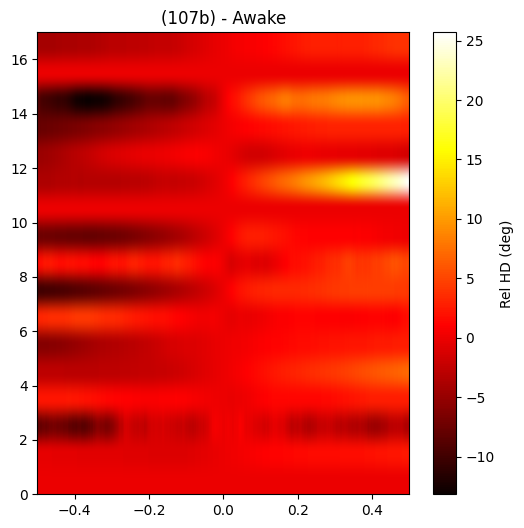

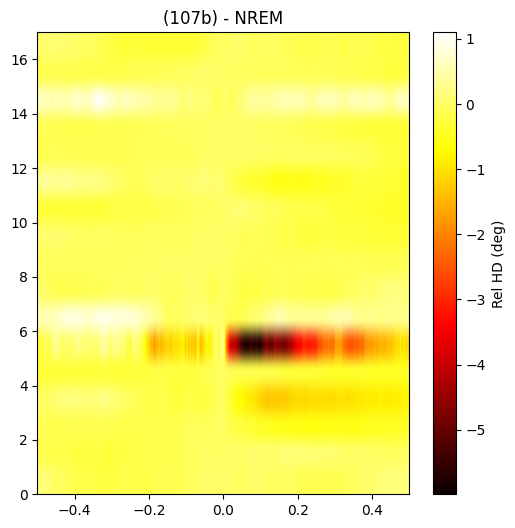

In [133]:
for sta in [sta_awake, sta_nrem]:
    zero_idx = np.where(sta.index == 0)[0].item()
    baseline = sta[zero_idx, :]
    sta_norm = sta - baseline
    plt.figure(figsize=(6, 6))
    im = plt.imshow(sta_norm.d[:, order].T, aspect='auto', origin='lower', extent=[sta_norm.index[0], sta_norm.index[-1], 0, sta_norm.shape[1]], cmap='hot')
    plt.colorbar(im, label='Rel HD (deg)')
    plt.title(f"({mouse_id}) - {'Awake' if sta is sta_awake else 'NREM'}")

### Turn amplitude

In [167]:
mv = "movement_var20"
subject_ids = ['99b', '107b']

sta_awake = []
sta_nrem = []
for mouse_id in subject_ids:
    data_dir = INTERIM_DIR  / mv / mouse_id
    if not data_dir.exists():
        continue

    sta_awake.append(nap.load_file(data_dir / "sta_awake.npz").d)
    sta_nrem.append(nap.load_file(data_dir / "sta_nrem.npz").d)

sta_awake = np.concatenate(sta_awake, axis=1)
sta_nrem = np.concatenate(sta_nrem, axis=1)
t = nap.load_file(data_dir / "sta_awake.npz").t

In [168]:
before_idx = np.where(t == -0.2)[0][0]
after_idx = np.where(t == 0.2)[0][0] + 1
awake_amp = sta_awake[after_idx, :] - sta_awake[before_idx, :]

turn_amps = []
for thresh in [0.02, 0.05, 0.2]:
    before_idx = np.where(t == -thresh)[0][0]
    after_idx = np.where(t == thresh)[0][0] + 1
    turn_amp = sta_nrem[after_idx, :] - sta_nrem[before_idx, :]
    turn_amps.append(turn_amp)
turn_amps = np.column_stack(turn_amps)

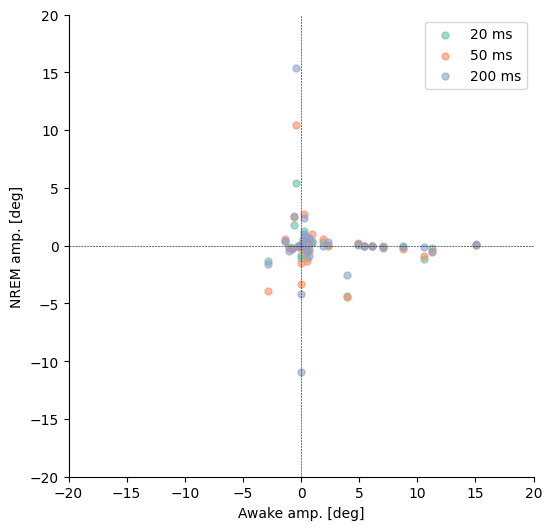

In [187]:
fig, ax = plt.subplots(figsize=(6, 6))

for i, thresh in enumerate([0.02, 0.05, 0.2]):
    ax.scatter(awake_amp, turn_amps[:, i], label=f"{(thresh * 1000):.0f} ms", color=cm(i), s=25, alpha=0.6)

ax.set_xlabel("Awake amp. [deg]")
ax.set_ylabel("NREM amp. [deg]")

ax.set_ylim(-20, 20)
ax.set_xlim(-20, 20)

ax.axhline(0, color='k', linestyle='--', linewidth=0.4)
ax.axvline(0, color='k', linestyle='--', linewidth=0.4)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.legend()